In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Housing.csv")

In [2]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


I choose this dataset because it is one of the most famous ML datasets and is excellent for EDA. It is also suitable for linear regression and can later be improved with the Decision Trees and Random Forests. I want to predict the price of the house based on all the other factors.

In [6]:
df.shape

(545, 13)

In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [15]:
df.isnull().sum()
'''no null value in any columns'''

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [11]:
df.duplicated()
'''No duplicate any any rows.'''

np.int64(0)

There are no null or duplicate values in the dataset so we let it be as it is and do not do unneccsary changes in it.

In [16]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [17]:
df["price"].median()

4340000.0

In [20]:
df["price"].mean()

np.float64(4766729.247706422)

In [21]:
df["price"].max()

13300000

For target variable **price** -

Mean is Rs.4766729

Max is Rs.13300000

Min is Rs.1750000

Median is Rs.4340000


**Observations -**

i)The max price of a house is Rs 1,33,00,000 crores.

ii)The smallest you can have is 1650 sq.ft of an apartment.

iii)The most biggest House is 6BHK.

iv)You can have mostly 4 floors of house.

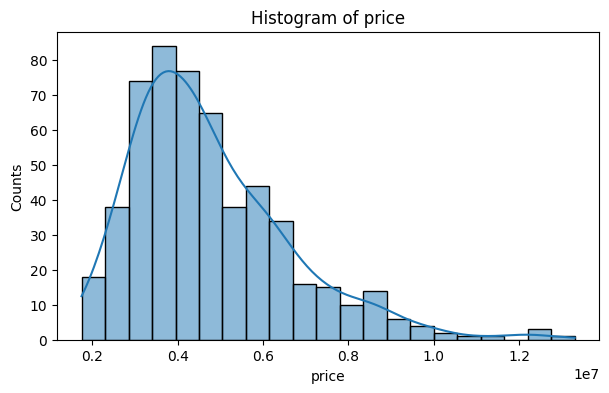

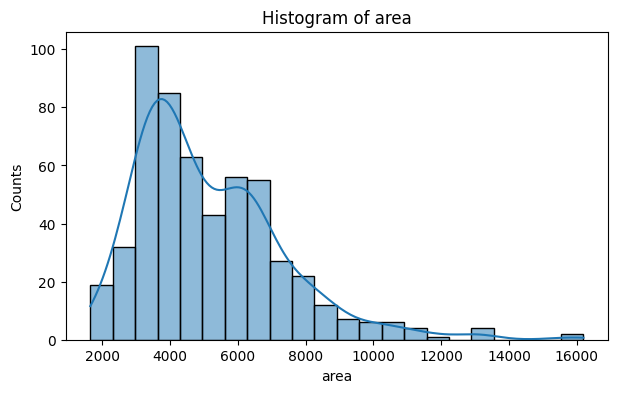

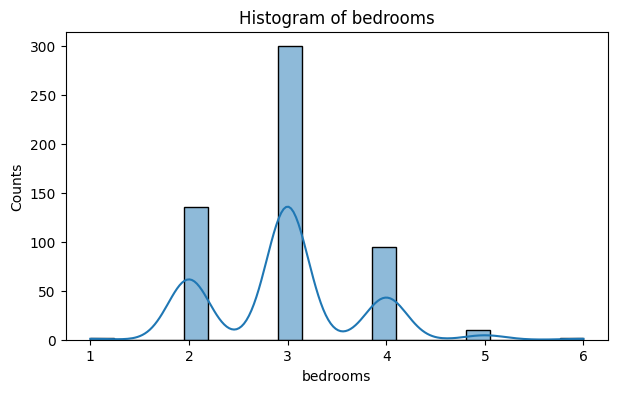

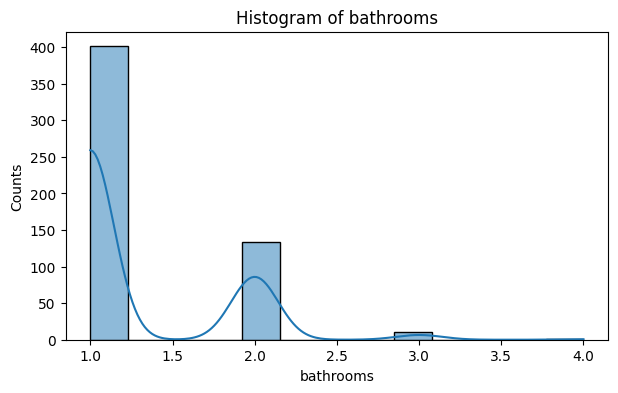

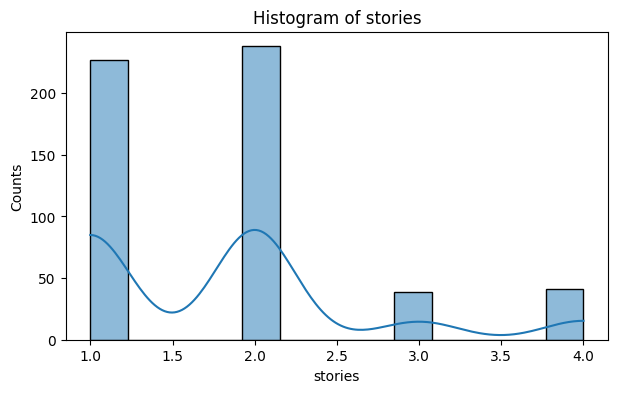

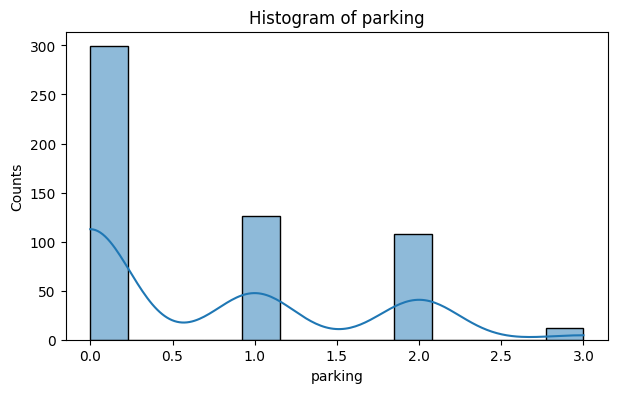

In [23]:
numeric_columns = ["price","area","bedrooms","bathrooms","stories","parking"]

for column in numeric_columns:
  plt.figure(figsize=(7,4))
  sns.histplot(df[column],kde=True)
  plt.title(f"Histogram of {column}")
  plt.xlabel(column)
  plt.ylabel("Counts")
  plt.show()

***Price Histogram -***

Most houses are distributed around the price of 20L to 60L.


***Area Histogram -***

Most Houses are distributed around 3000 sq.ft to 7000 sq.ft


***Bedrooms Histogram -***

We have most houses as 3BHK followed by 2 and 4.

***Bathrooms Histogram -***

Most houses have 1 bathroom only.

***Stories Histogram -***

People also prefer to have 2 floors house over 1 floor.

In [24]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

All categorical columns are - **['mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus']**

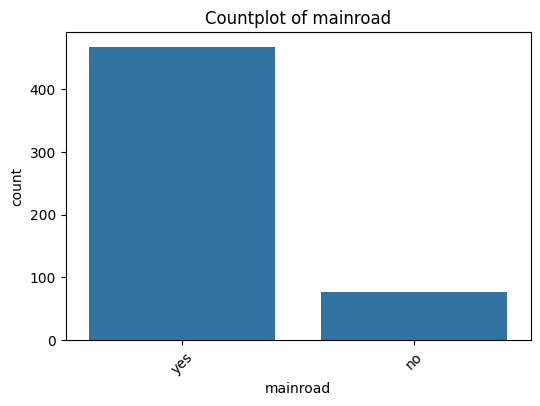

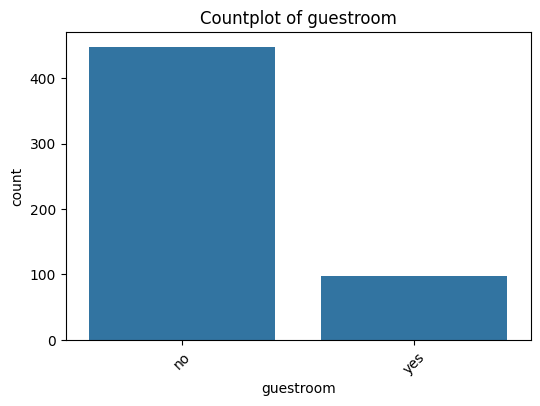

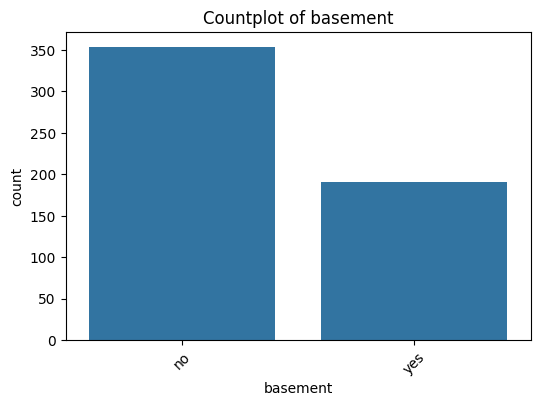

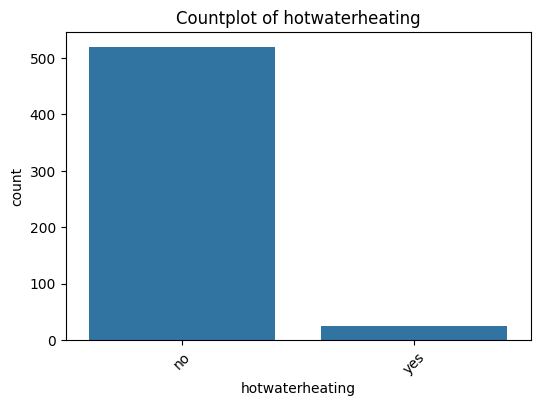

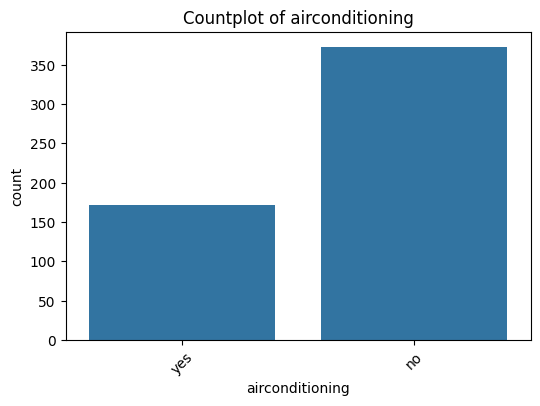

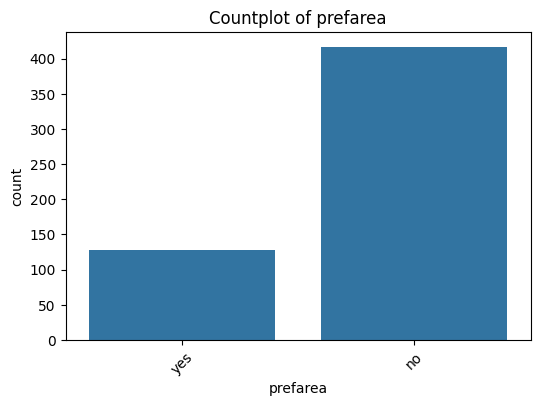

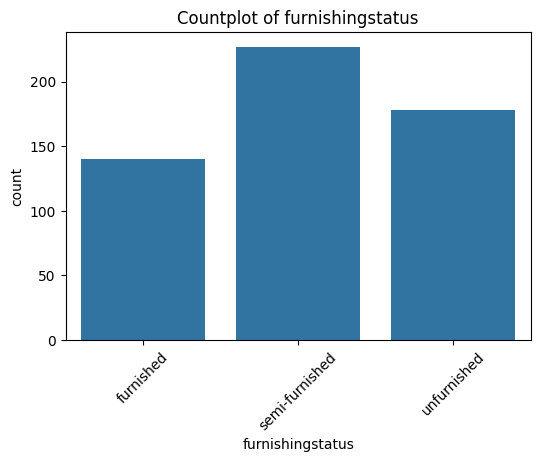

In [28]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
  plt.figure(figsize=(6,4))
  sns.countplot(data = df,x = column)
  plt.title(f"Countplot of {column}")
  plt.xticks(rotation = 45)
  plt.show()

***Mainroad plot -***

Most houses are located roadsight.


***Guestroom plot -***

Most Houses do not have the facility of having a guestroom.


***Basement plot -***

Appox 200 houses have the basement and the rest don't.

***Hotwater plot -***

Only very few houses have the facility of having hot water heating and rest doesn't.

***AirConditioning plot -***

More then 350 houses do not have an airconditioner

***prefarea plot -***

only around 125 house owners have got there house in their preferrd area.

***furnishingstaus plot -***

The distribution of the furniture status is quite evenly spread while most houses remain unfurnished.

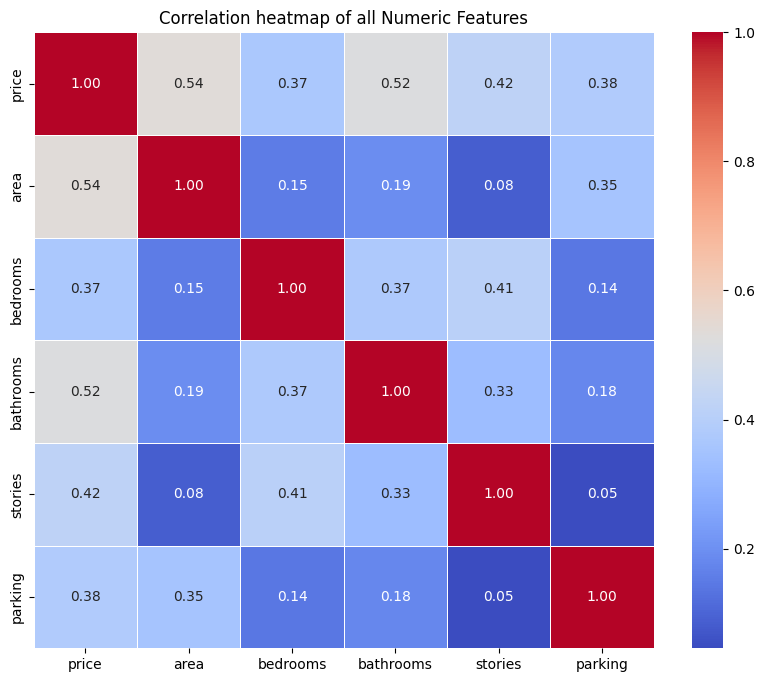

In [29]:
numeric_df = df.select_dtypes(include=["int64","float64"])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr_matrix,annot=True,cmap = "coolwarm",fmt=".2f",linewidths=0.5)

plt.title("Correlation heatmap of all Numeric Features")

plt.show()

Area and Bathrooms are highly correlated with the price, followed by stories,bedrooms and parking.

So, we can safely say that any increment in the other columns will definitely have a positive effect on the price.

***Independent Features (X)*** — 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus


***Dependent Feature (y)*** — price

So we want to calculate the price of the house therefore any factor whether area or parking, every factor have positive affect on the price of the house.


In [30]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [33]:
print("Before Transformation -")
print(df.head())

encoded_df = pd.get_dummies(df,drop_first=False)

print("After Transformation -")
print(encoded_df.head())

Before Transformation -
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
After Transformation -
      price  area  bedrooms  bathrooms  stories  par

So, we encoded all the categorical columns to numerical so that we can feed it to the model so that it can learn from the categories too.

In [35]:
X = encoded_df.drop("price", axis=1)
y = encoded_df["price"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
print(X_scaled)
X_scaled = pd.DataFrame(X_scaled,columns=X.columns)

print("First 5 Rows of Scaled Features:\n")
print(X_scaled.head())

[[ 1.04672629  1.40341936  1.42181174 ...  1.70084013 -0.84488844
  -0.6964292 ]
 [ 1.75700953  1.40341936  5.40580863 ...  1.70084013 -0.84488844
  -0.6964292 ]
 [ 2.21823241  0.04727831  1.42181174 ... -0.58794474  1.18358821
  -0.6964292 ]
 ...
 [-0.70592066 -1.30886273 -0.57018671 ... -0.58794474 -0.84488844
   1.43589615]
 [-1.03338891  0.04727831 -0.57018671 ...  1.70084013 -0.84488844
  -0.6964292 ]
 [-0.5998394   0.04727831 -0.57018671 ... -0.58794474 -0.84488844
   1.43589615]]
First 5 Rows of Scaled Features:

       area  bedrooms  bathrooms   stories   parking  mainroad_no  \
0  1.046726  1.403419   1.421812  1.378217  1.517692    -0.405623   
1  1.757010  1.403419   5.405809  2.532024  2.679409    -0.405623   
2  2.218232  0.047278   1.421812  0.224410  1.517692    -0.405623   
3  1.083624  1.403419   1.421812  0.224410  2.679409    -0.405623   
4  1.046726  1.403419  -0.570187  0.224410  1.517692    -0.405623   

   mainroad_yes  guestroom_no  guestroom_yes  basement_no  

# ***Task 20 Optional from here***

We are making a model!

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (436, 20)
Shape of X_test: (109, 20)
Shape of y_train: (436,)
Shape of y_test: (109,)


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
comparison = pd.DataFrame({"Actual Price": y_test.values,"Predicted Price": y_pred})

print(comparison.head(10))

   Actual Price  Predicted Price
0       4060000     5.164654e+06
1       6650000     7.224722e+06
2       3710000     3.109863e+06
3       6440000     4.612075e+06
4       2800000     3.294646e+06
5       4900000     3.532275e+06
6       5250000     5.611775e+06
7       4543000     6.368146e+06
8       2450000     2.722857e+06
9       3353000     2.629406e+06


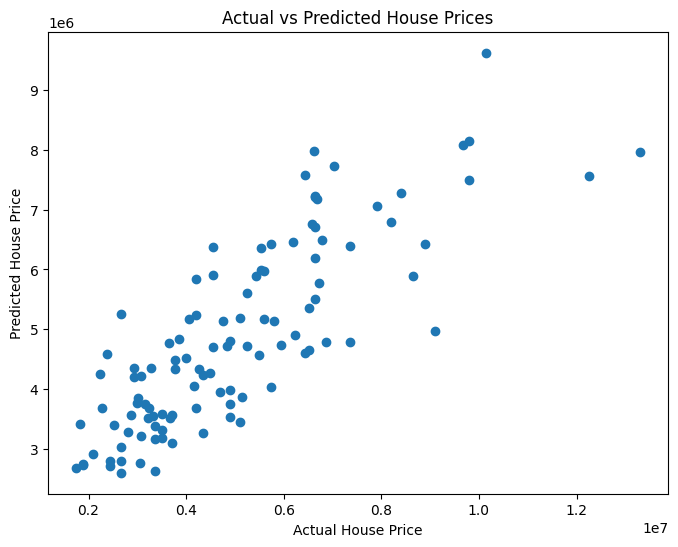

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.6529242642153175


In [ ]:
import joblib

joblib.dump(model, "HousePriceModel.pkl")
joblib.dump(scaler, "HouseScaler.pkl")
joblib.dump(X.columns.tolist(), "HouseColumns.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
